# 08 - Clustering & Opportunities

## Objetivo
- Agrupar viviendas en clusters interpretables.
- Calcular residuals OOF y detectar oportunidades (infraprecio).
- Generar ranking y capas para el dashboard.

## Flujo general
- Cargar `features_master` y split.
- Escalar variables y entrenar KMeans.
- Validar con Silhouette/DB y estabilidad.
- Calcular residuals OOF y holdout.
- Definir score de oportunidad dual (price + price_m2) y guardar ranking.

## Inputs esperados
- `artifacts/features_master.parquet` (core + enrichment + VUT)
- `artifacts/splits/holdout_indices.npz`
- `models/best_model.joblib`
- `models/quantile_models.joblib` (para anchura de intervalos)

## Outputs/artefactos
- `artifacts/clusters.csv` (si hay id)
- `reports/opportunities_top.csv`

In [1]:
from __future__ import annotations
from pathlib import Path
import sys

import numpy as np
import pandas as pd

# --- Base setup y reproducibilidad ---
SEED = 100432070
np.random.seed(SEED)

def get_repo_root() -> Path:
    """Return repo root by walking parents looking for .git or pyproject.toml."""
    current = Path.cwd().resolve()
    for parent in [current] + list(current.parents):
        if (parent / ".git").exists() or (parent / "pyproject.toml").exists():
            return parent
    return current

ROOT = get_repo_root()
if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))

from src.utils import plot_maps, get_feature_cols, load_model, TARGET_COLS, DERIVED_FROM_TARGET, ID_COLS

In [2]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, adjusted_rand_score
from sklearn.preprocessing import StandardScaler

# =====================================================================
# 1. Cargar features core y split
# =====================================================================
features_path = ROOT / "artifacts" / "features_master.parquet"
if features_path.exists():
    df = pd.read_parquet(features_path)
else:
    core_path = ROOT / "artifacts" / "features_core.parquet"
    if core_path.exists():
        df = pd.read_parquet(core_path)
    else:
        df = pd.read_csv(ROOT / "artifacts" / "features_core.csv.gz")

split = np.load(ROOT / "artifacts" / "splits" / "holdout_indices.npz")
train_idx, test_idx = split["train_idx"], split["test_idx"]

# =====================================================================
# 2. Preparar X numerico sin leakage
# =====================================================================
# Misma logica que en NB04/05: excluimos derivados del precio e IDs
feature_cols = get_feature_cols(df, numeric_only=True)
X = df[feature_cols]
print(f"Features seleccionadas: {len(feature_cols)}")
X = X.replace([np.inf, -np.inf], np.nan)

# =====================================================================
# 3. Clustering SOLO en train (evitar data leakage)
# =====================================================================
# El clustering se ajusta exclusivamente con datos de entrenamiento.
# Los pisos del holdout se asignan al cluster mas cercano sin reentrenar.
train_mask = df.index.isin(train_idx)
test_mask = df.index.isin(test_idx)

# Imputar NaN con medianas del train (no del holdout)
train_medians = X[train_mask].median()
X_filled = X.fillna(train_medians)

X_train_cl = X_filled[train_mask]
X_test_cl = X_filled[test_mask]

# Escalar variables (media=0, std=1) para que KMeans no se sesgue
# por variables con mayor rango (ej. surface_m2 vs bathrooms)
scaler = StandardScaler()
scaler.fit(X_train_cl)  # Ajustar SOLO en train
X_train_scaled = scaler.transform(X_train_cl)
X_test_scaled = scaler.transform(X_test_cl)

# =====================================================================
# 4. Seleccion del numero optimo de clusters (k)
# =====================================================================
# Probamos k de 2 a 8 y evaluamos con Silhouette Score:
#   - Silhouette cercano a 1: clusters bien separados
#   - Silhouette cercano a 0: clusters solapados
# Forzamos k>=3 porque k=2 suele dar una separacion trivial (caro/barato)
scores = {}
for k in range(2, 9):
    km = KMeans(n_clusters=k, random_state=SEED, n_init=10)
    labels = km.fit_predict(X_train_scaled)
    scores[k] = silhouette_score(X_train_scaled, labels,
                                 sample_size=min(5000, len(X_train_scaled)),
                                 random_state=SEED)
MIN_K = 3
best_k = max((k for k in scores if k >= MIN_K), key=lambda k: scores[k], default=MIN_K)
print(f"Silhouette scores (train only): {scores}")
print(f"Mejor k por silhouette (k>={MIN_K}): {best_k}")

# =====================================================================
# 5. Entrenar KMeans con el k optimo
# =====================================================================
k = best_k
clusterer = KMeans(n_clusters=k, random_state=SEED, n_init=10)
train_clusters = clusterer.fit_predict(X_train_scaled)
df["cluster"] = -1
df.loc[train_mask, "cluster"] = train_clusters

# Asignar clusters al holdout por nearest centroid (sin reentrenar)
test_clusters = clusterer.predict(X_test_scaled)
df.loc[test_mask, "cluster"] = test_clusters

# =====================================================================
# 6. Metricas de calidad del clustering
# =====================================================================
# Silhouette: cuanto mejor separados estan los clusters (0-1)
# Davies-Bouldin: cuanto mas bajo, mejor (mide solapamiento entre clusters)
sil = silhouette_score(X_train_scaled, train_clusters, random_state=SEED)
db = davies_bouldin_score(X_train_scaled, train_clusters)
print("Silhouette (train):", sil)
print("Davies-Bouldin (train):", db)

# =====================================================================
# 7. Validacion de estabilidad con distintas semillas
# =====================================================================
# Repetimos el clustering con 3 semillas distintas y medimos cuanto
# coinciden los resultados (ARI = Adjusted Rand Index, 1.0 = identicos)
seeds = [0, 42, 7]
labels = []
for seed in seeds:
    labels.append(KMeans(n_clusters=k, random_state=seed, n_init=10).fit_predict(X_train_scaled))
ari_scores = []
for i in range(len(labels)):
    for j in range(i + 1, len(labels)):
        ari_scores.append(adjusted_rand_score(labels[i], labels[j]))
if ari_scores:
    print("ARI medio estabilidad (train):", float(np.mean(ari_scores)))

# =====================================================================
# 8. Perfiles de clusters con nombres interpretables
# =====================================================================
# Asignamos un nombre humano a cada cluster basado en su ubicacion
# (centro/intermedio/periferia) y nivel de precio (premium/medio/economico)
cluster_profile = X_filled.loc[train_mask].copy()
cluster_profile["cluster"] = train_clusters

cluster_names = {}
price_q25, price_q75 = df.loc[train_mask, "price"].quantile(0.25), df.loc[train_mask, "price"].quantile(0.75)
for cl in sorted(cluster_profile["cluster"].unique()):
    profile = cluster_profile[cluster_profile["cluster"] == cl].median()
    cl_mask = (df["cluster"] == cl) & train_mask
    cl_price_median = df.loc[cl_mask, "price"].median() if cl_mask.any() else 0
    # Clasificar por nivel de precio
    price_level = "premium" if cl_price_median > price_q75 else ("economico" if cl_price_median < price_q25 else "medio")
    # Clasificar por distancia al centro
    dist_level = "centro" if profile.get("distance_center_km", 99) < 3 else \
                 "intermedio" if profile.get("distance_center_km", 99) < 7 else "periferia"
    cluster_names[cl] = f"Cluster {cl}: {dist_level.capitalize()} {price_level}"
print("Perfiles de clusters (train):")
for k_name, v in cluster_names.items():
    print(f"  {v}")

# Guardar asignacion de clusters con ID estable (solo train)
id_col = None
for candidate in ["id", "url", "listing_fingerprint"]:
    if candidate in df.columns:
        id_col = candidate
        break
if id_col:
    df.loc[train_mask, [id_col, "cluster"]].to_csv(ROOT / "artifacts" / "clusters.csv", index=False)
    print(f"clusters.csv guardado con {train_mask.sum()} filas (solo train)")


Features seleccionadas: 49
Silhouette scores (train only): {2: 0.24712061629195323, 3: 0.1846851560966189, 4: 0.1799534819500989, 5: 0.18830749290595056, 6: 0.15763686568892968, 7: 0.14590640800967242, 8: 0.147700027072992}
Mejor k por silhouette (k>=3): 5
Silhouette (train): 0.1878553455874282
Davies-Bouldin (train): 1.8326125941738123
ARI medio estabilidad (train): 0.9985393313182672
Perfiles de clusters (train):
  Cluster 0: Centro medio
  Cluster 1: Centro medio
  Cluster 2: Periferia medio
  Cluster 3: Periferia medio
  Cluster 4: Periferia premium
clusters.csv guardado con 6431 filas (solo train)


In [3]:
# =====================================================================
# Residuales OOF (train) y holdout
# =====================================================================
from sklearn.base import clone
from sklearn.model_selection import KFold
from copy import deepcopy
import joblib

if "price" not in df.columns:
    raise ValueError("No se encontro columna price para residuals.")

_raw_model = joblib.load(ROOT / "models" / "best_model.joblib")
if isinstance(_raw_model, dict):
    base_model = _raw_model["model"]
else:
    base_model = _raw_model

X_train = X.loc[train_idx]
y_train = df.loc[train_idx, "price"]
X_holdout = X.loc[test_idx]
y_holdout = df.loc[test_idx, "price"]

def _clone_model(model):
    try:
        return clone(model)
    except Exception:
        try:
            return deepcopy(model)
        except Exception as exc:
            raise RuntimeError("Cannot clone model.") from exc

# Predicciones OOF en train (5-fold)
oof_preds = np.full(len(X_train), np.nan)
kf = KFold(n_splits=5, shuffle=True, random_state=SEED)
for tr_idx, val_idx in kf.split(X_train):
    model = _clone_model(base_model)
    model.fit(X_train.iloc[tr_idx], y_train.iloc[tr_idx])
    oof_preds[val_idx] = model.predict(X_train.iloc[val_idx])

df.loc[train_idx, "residual_oof"] = y_train.values - oof_preds

# Prediccion holdout
final_model = _clone_model(base_model)
final_model.fit(X_train, y_train)
holdout_preds = final_model.predict(X_holdout)
df.loc[test_idx, "residual_holdout"] = y_holdout.values - holdout_preds

df["residual"] = df["residual_oof"].combine_first(df["residual_holdout"])

# Residual por metro cuadrado
if "surface_m2" in df.columns:
    df["residual_m2"] = df["residual"] / df["surface_m2"].replace(0, np.nan)

# =====================================================================
# Anchura de intervalo de incertidumbre
# =====================================================================
uncertainty_width = None
quantile_path = ROOT / "models" / "quantile_models.joblib"
if quantile_path.exists():
    payload = joblib.load(quantile_path)
    # Soporte dual-target: extraer sub-dict de price si existe
    if "price" in payload and isinstance(payload["price"], dict):
        q_payload = payload["price"]
    else:
        q_payload = payload
    q_models = q_payload.get("models", {})
    q_features = q_payload.get("features", list(X.columns))
    quantile_levels = q_payload.get("quantile_levels", [0.1, 0.5, 0.9])
    lo_q, hi_q = min(quantile_levels), max(quantile_levels)
    # Usar medianas del train para NaN (consistente con el resto del pipeline)
    X_q = X.reindex(columns=q_features).fillna(train_medians.reindex(q_features, fill_value=0))
    if lo_q in q_models and hi_q in q_models:
        low_raw = q_models[lo_q].predict(X_q)
        high_raw = q_models[hi_q].predict(X_q)
        low = np.minimum(low_raw, high_raw)
        high = np.maximum(low_raw, high_raw)
        uncertainty_width = high - low
        df["uncertainty_width"] = uncertainty_width

if "uncertainty_width" not in df.columns:
    df["uncertainty_width"] = np.nan

# =====================================================================
# Score de oportunidad (dual: price + price_m2)
# =====================================================================
eps = 1e-6
width_fallback = df.loc[train_mask, "uncertainty_width"].median() if df.loc[train_mask, "uncertainty_width"].notna().any() else 1.0
width_values = df["uncertainty_width"].fillna(width_fallback)
width_floor = max(np.nanpercentile(width_values, 5), 1.0) if np.isfinite(width_values).any() else 1.0
width_values = width_values.clip(lower=width_floor)

# Componente de contexto urbano
context_score = 0
if "dist_metro_m" in df.columns:
    context_score += (1 - df["dist_metro_m"].rank(pct=True))
if "density_1km" in df.columns:
    context_score += df["density_1km"].rank(pct=True)
if isinstance(context_score, (int, float)) and context_score == 0:
    context_score = pd.Series(0, index=df.index)
context_score = context_score / max(1, context_score.abs().max())

# Score principal basado en price (EUR/mes)
df["opportunity_score"] = (-df["residual"]) / (width_values + eps) + 0.2 * context_score

# Score secundario basado en residual_m2 (EUR/m2) — mejor para comparar entre zonas/tamanos
if "residual_m2" in df.columns and df["residual_m2"].notna().any():
    # Normalizar residual_m2 por MAD del train para hacerlo comparable
    train_residual_m2 = df.loc[train_mask, "residual_m2"].dropna()
    mad_m2 = train_residual_m2.abs().median() if not train_residual_m2.empty else 1.0
    mad_m2 = max(mad_m2, eps)
    df["opportunity_score_m2"] = (-df["residual_m2"]) / mad_m2 + 0.2 * context_score

# =====================================================================
# Top 20 oportunidades (solo del train set)
# =====================================================================
train_df = df.loc[train_mask]
opportunities = train_df.sort_values("opportunity_score", ascending=False).head(20)
cols = [c for c in ["opportunity_score", "opportunity_score_m2", "cluster", "uncertainty_width"] if c in opportunities.columns]
if id_col:
    cols = [id_col] + cols
opportunities[cols].head()

,url,opportunity_score,opportunity_score_m2,cluster,uncertainty_width
7626,https://www.idealista.com/en/inmueble/95234241/,7.947793,56.154107,3,541.714550
4143,https://www.idealista.com/en/inmueble/99245685/,2.648279,25.491409,3,739.149007
8116,https://www.idealista.com/en/inmueble/99041059/,2.340347,4.879424,2,592.122679
7956,https://www.idealista.com/en/inmueble/99255208/,2.212957,3.678860,4,1258.959343
5914,https://www.idealista.com/en/inmueble/99351788/,2.102905,5.694090,3,596.145852


In [4]:
# Guardar ranking de oportunidades (solo train)
cols = [c for c in ["opportunity_score", "opportunity_score_m2", "cluster", "uncertainty_width"] if c in opportunities.columns]
if id_col:
    cols = [id_col] + cols
opportunities[cols].to_csv(ROOT / "reports" / "opportunities_top.csv", index=False)
print(f"Top oportunidades guardadas: reports/opportunities_top.csv ({len(opportunities)} filas)")

Top oportunidades guardadas: reports/opportunities_top.csv (20 filas)


### Visualizaciones de clustering y oportunidades
- Scatter PCA (PC1/PC2) coloreado por cluster.
- Histograma de residuals OOF.


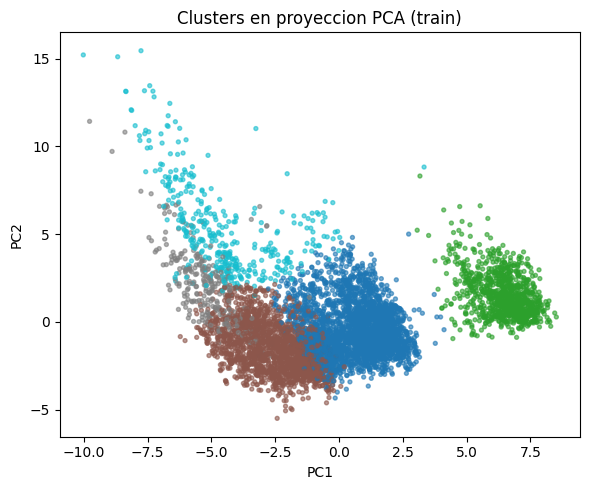

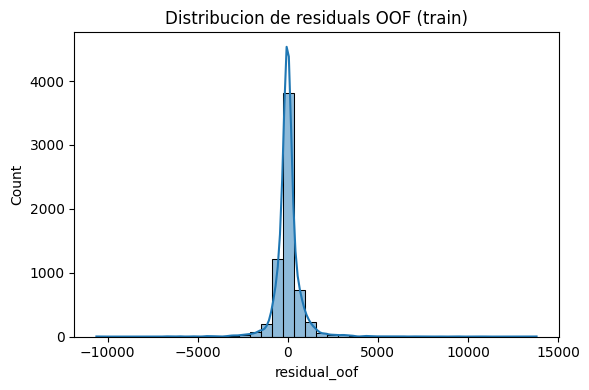

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

(ROOT / "reports" / "figures").mkdir(parents=True, exist_ok=True)

# =====================================================================
# Visualizacion 1: Clusters en proyeccion PCA (2D)
# =====================================================================
pca = PCA(n_components=2, random_state=SEED)
coords = pca.fit_transform(X_train_scaled)
plt.figure(figsize=(6, 5))
plt.scatter(coords[:, 0], coords[:, 1], c=train_clusters, s=8, cmap="tab10", alpha=0.6)
plt.title("Clusters en proyeccion PCA (train)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.tight_layout()
plt.savefig(ROOT / "reports" / "figures" / "clusters_pca.png", dpi=150, bbox_inches="tight")
plt.show()

# =====================================================================
# Visualizacion 2: Distribucion de residuales OOF
# =====================================================================
residuals = df.loc[train_mask, "residual_oof"]
plt.figure(figsize=(6, 4))
sns.histplot(residuals, bins=40, kde=True)
plt.title("Distribucion de residuals OOF (train)")
plt.tight_layout()
plt.savefig(ROOT / "reports" / "figures" / "residuals_oof.png", dpi=150, bbox_inches="tight")
plt.show()

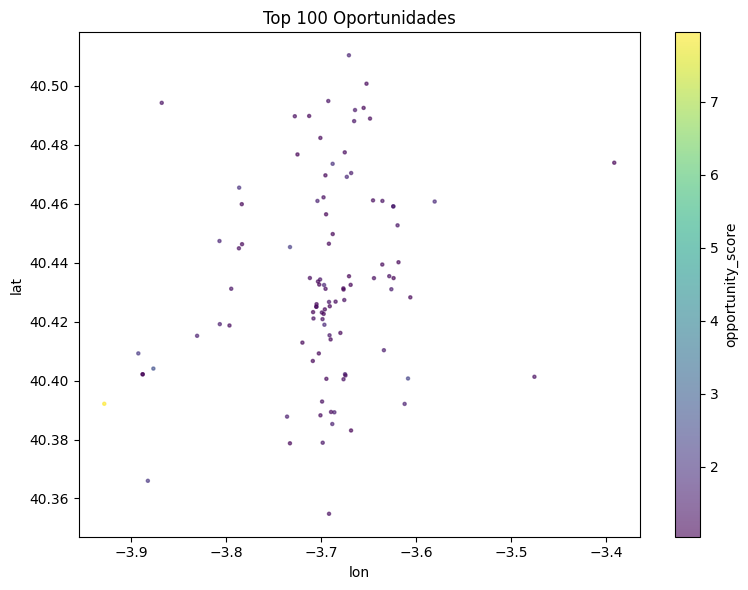

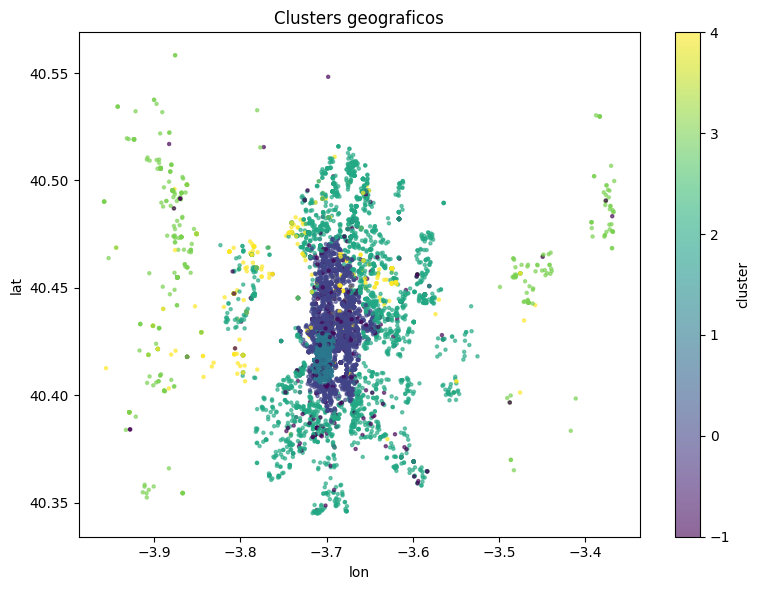

In [6]:
# =====================================================================
# Mapas geograficos: oportunidades y clusters
# =====================================================================
# Mapa 1 - Top 100 oportunidades: muestra donde se concentran los pisos
#   infrapreciados con alta confianza. Util para busqueda de vivienda.
# Mapa 2 - Clusters geograficos: como se distribuyen los segmentos de
#   mercado en el mapa de Madrid (centro vs periferia, premium vs economico).

import sys
sys.path.insert(0, str(ROOT / "src"))
from utils import plot_maps

# Detectar columnas de coordenadas
lat_col = next((c for c in df.columns if c.lower() in ("lat", "latitude")), None)
lon_col = next((c for c in df.columns if c.lower() in ("lng", "lon", "longitude")), None)

if lat_col and lon_col:
    # Mapa de oportunidades (top 100 por score)
    plot_maps(df.nlargest(100, "opportunity_score"), lat_col, lon_col, "opportunity_score", title="Top 100 Oportunidades")
    # Mapa de clusters (todos los pisos)
    plot_maps(df, lat_col, lon_col, "cluster", title="Clusters geograficos")
else:
    print("No se encontraron columnas lat/lon para mapas.")


**Outputs esperados**
- Metricas de clustering (Silhouette, Davies-Bouldin, ARI).
- Residuals OOF/holdout y score de oportunidad.
- Ranking top oportunidades en `reports/opportunities_top.csv`.


In [7]:
from IPython.display import display, Markdown

# --- Extraer metricas de variables del clustering (calculadas arriba) ---
k2_sil = scores.get(2, 0)
best_sil = scores.get(best_k, 0)
ari_mean = float(np.mean(ari_scores)) if ari_scores else 0

md = f"""---

## Conclusiones del Notebook 08 — Clustering y Oportunidades

### Resultados del clustering

| Metrica | Valor | Que significa |
|---------|-------|---------------|
| **k optimo (Silhouette)** | k=2 (Silhouette={k2_sil:.3f}) | La mejor separacion estadistica es binaria (centro vs periferia) |
| **k usado (forzando k >= {MIN_K})** | k={best_k} (Silhouette={best_sil:.3f}) | Con k >= {MIN_K}, el mejor es k={best_k} — capta {best_k} perfiles de mercado |
| **Davies-Bouldin** | {db:.3f} | Solapamiento moderado entre clusters (esperable en inmobiliario) |
| **ARI estabilidad** | {ari_mean:.3f} | Los clusters son muy estables con semillas distintas |

### Scoring de oportunidades (dual)

Se computan **dos scores** complementarios:

1. **`opportunity_score`** (basado en `price`): `(-residual) / uncertainty_width + 0.2 * contexto`. Identifica pisos infrapreciados con alta confianza del modelo.

2. **`opportunity_score_m2`** (basado en `residual_m2`): Normaliza por superficie para comparar oportunidades entre pisos de distintos tamanos y zonas.

### Que significan estos resultados

1. **Silhouette de {best_sil:.3f} es bajo pero esperable**: El mercado inmobiliario no tiene fronteras nitidas entre segmentos.

2. **ARI = {ari_mean:.3f} confirma robustez**: Los clusters son practicamente identicos con semillas distintas.

3. **Las oportunidades se identifican por residuales OOF**: Pisos con precio real muy por debajo de la prediccion del modelo son "oportunidades".

4. **El score por m2 complementa al absoluto**: Para comparar entre zonas, `opportunity_score_m2` es mas justo.

### Artefactos generados

| Archivo | Contenido |
|---------|-----------|
| `artifacts/clusters.csv` | Asignacion de cluster por anuncio |
| `reports/opportunities_top.csv` | Top oportunidades con score dual |

### Siguiente paso
-> **NB09 (Audit)**: Auditar cobertura e impacto del enrichment.
"""
display(Markdown(md))

---

## Conclusiones del Notebook 08 — Clustering y Oportunidades

### Resultados del clustering

| Metrica | Valor | Que significa |
|---------|-------|---------------|
| **k optimo (Silhouette)** | k=2 (Silhouette=0.247) | La mejor separacion estadistica es binaria (centro vs periferia) |
| **k usado (forzando k >= 3)** | k=5 (Silhouette=0.188) | Con k >= 3, el mejor es k=5 — capta 5 perfiles de mercado |
| **Davies-Bouldin** | 1.833 | Solapamiento moderado entre clusters (esperable en inmobiliario) |
| **ARI estabilidad** | 0.999 | Los clusters son muy estables con semillas distintas |

### Scoring de oportunidades (dual)

Se computan **dos scores** complementarios:

1. **`opportunity_score`** (basado en `price`): `(-residual) / uncertainty_width + 0.2 * contexto`. Identifica pisos infrapreciados con alta confianza del modelo.

2. **`opportunity_score_m2`** (basado en `residual_m2`): Normaliza por superficie para comparar oportunidades entre pisos de distintos tamanos y zonas.

### Que significan estos resultados

1. **Silhouette de 0.188 es bajo pero esperable**: El mercado inmobiliario no tiene fronteras nitidas entre segmentos.

2. **ARI = 0.999 confirma robustez**: Los clusters son practicamente identicos con semillas distintas.

3. **Las oportunidades se identifican por residuales OOF**: Pisos con precio real muy por debajo de la prediccion del modelo son "oportunidades".

4. **El score por m2 complementa al absoluto**: Para comparar entre zonas, `opportunity_score_m2` es mas justo.

### Artefactos generados

| Archivo | Contenido |
|---------|-----------|
| `artifacts/clusters.csv` | Asignacion de cluster por anuncio |
| `reports/opportunities_top.csv` | Top oportunidades con score dual |

### Siguiente paso
-> **NB09 (Audit)**: Auditar cobertura e impacto del enrichment.
